# Possession Values Tutorial

# ⚽️ Event-Based Pass Valuation Models  
### Section 1 – Data Loading & Possession Outcome Construction  

In this section we:
1. Load all **SkillCorner dynamic event** files from `PremierLeague_data/2024/dynamic`.  
2. Keep only **on-ball actions** (`player_possession` events).  
3. Assign **possession IDs** — defining a new possession when  
   - the team changes **and** there are **≥ 2 consecutive opponent actions**, or  
   - the period changes, or  
   - the time gap between actions > 10 s.  
4. Compute **outcome labels** used later by xT, VAEP, and G⁺:  
   - `shot_EOP`, `goal_EOP` – at end of possession  
   - `shot_10s`, `goal_10s` – within 10 seconds after an event  
   - `shot_10a`, `goal_10a` – within 10 actions after an event  
5. Save one cleaned file per match to `PROCESSED_DIR`.

After this step every processed file will be directly usable for xT / VAEP / G⁺ modeling.




## 🧩 1.1 – Imports & paths


In [6]:

import os
from pathlib import Path
import pandas as pd
import numpy as np
import os, json


# --- Paths (as provided) ---
ROOT = Path.cwd().parents[0]
DYNAMIC_DIR = ROOT / "PremierLeague_data/2024/dynamic"
META_DIR = ROOT / "PremierLeague_data/2024/meta"
PROCESSED_DIR = ROOT / "PremierLeague_data/2024/processed"
PROCESSED_DIR.mkdir(exist_ok=True)

# Pitch constants (SkillCorner → 105 × 68 m, origin at left-bottom)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105.0, 68.0


In [7]:
# Cell 1: build/refresh matches index (id, home_team, away_team)

matches_file = ROOT / "matches.parquet"
if not matches_file.exists():
    rows = []
    for fpath in DYNAMIC_DIR.glob("*.parquet"):
        match_id = int(fpath.stem)
        meta_path = META_DIR / f"{match_id}.json"
        home_team = away_team = None
        if meta_path.exists():
            with open(meta_path, "r") as f:
                meta = json.load(f)
            home_team = meta["home_team"]["name"]
            away_team = meta["away_team"]["name"]
        rows.append({"id": match_id, "home_team": home_team, "away_team": away_team})
    df_matches = pd.DataFrame(rows)
    df_matches.to_parquet(matches_file, index=False)
else:
    df_matches = pd.read_parquet(matches_file)

print(f"✅ Matches loaded: {len(df_matches)}")
df_matches.head()


✅ Matches loaded: 378


,id,home_team,away_team
0,1986708,Crystal Palace,Brentford FC
1,1715920,Tottenham Hotspur,Arsenal Football Club
2,2015001,West Ham United,Tottenham Hotspur
3,1650385,Manchester United,Fulham
4,2007863,Leicester City,Manchester United


In [8]:
match_id = df_matches.id.loc[0]  
fpath = DYNAMIC_DIR / f"{match_id}.parquet"
ev = pd.read_parquet(fpath)
ev= ev[ev['event_type']== 'player_possession']
print(f"Loaded {len(ev):,} rows for match {match_id}")
ev.head(3)

Loaded 757 rows for match 1986708


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,1986708,11,11,NaN,00:00.1,00:00.1,0,0,...,NaN,NaN,NaN,NaN,NaN,True,True,None,False,False
2,8_1,2,1986708,30,61,NaN,00:02.0,00:05.1,0,2,...,NaN,NaN,NaN,NaN,NaN,False,False,True,True,True
10,8_2,10,1986708,123,127,NaN,00:11.3,00:11.7,0,11,...,NaN,NaN,NaN,NaN,NaN,True,True,None,True,False


In [9]:
ev.game_interruption_before.value_counts()

game_interruption_before
throw_in_for         25
free_kick_for        13
goal_kick_against    10
throw_in_against      9
corner_for            7
goal_kick_for         7
corner_against        3
goal_against          3
free_kick_against     2
Name: count, dtype: int64

In [10]:
ev.game_interruption_after.value_counts()

game_interruption_after
throw_in_against     20
throw_in_for         15
goal_kick_against    13
free_kick_for         9
free_kick_against     8
corner_for            7
corner_against        3
goal_for              2
goal_kick_for         1
penalty_for           1
Name: count, dtype: int64


## ⚙️ 1.2 – Utility functions  
We define small reusable helpers for possession detection and for adding horizon-based outcome labels.
"""


In [11]:
def convert_time_to_ms(df: pd.DataFrame) -> pd.DataFrame:
    """Convert time_start and time_end from 'MM:SS.s' strings to milliseconds."""
    def to_ms(t):
        if pd.isna(t):
            return np.nan
        if isinstance(t, (int, float)):
            return t  # already numeric
        try:
            parts = str(t).split(":")
            if len(parts) == 2:
                minutes, seconds = parts
                return (float(minutes) * 60 + float(seconds)) * 1000
        except Exception:
            return np.nan
        return np.nan

    df = df.copy()
    df["time_start_ms"] = df["time_start"].apply(to_ms)
    df["time_end_ms"]   = df["time_end"].apply(to_ms)
    return df


In [12]:
ev = convert_time_to_ms(ev)
ev[["time_start", "time_end", "time_start_ms", "time_end_ms"]].head()


,time_start,time_end,time_start_ms,time_end_ms
0,00:00.1,00:00.1,100.0,100.0
2,00:02.0,00:05.1,2000.0,5100.0
10,00:11.3,00:11.7,11300.0,11700.0
16,00:12.9,00:14.7,12900.0,14700.0
24,01:12.3,01:14.8,72300.0,74800.0


In [13]:
def assign_possessions(events_df):
    """
    Assign possession IDs and possession team IDs for all on-ball events.

    A new possession starts when:
      - There are ≥ 2 consecutive opponent actions, OR
      - The period changes, OR
      - The previous event's end_type is 'shot' or 'possession_loss'.

    Rules:
      - At most 1 opponent action can occur inside a team's possession (e.g., deflection, duel).
      - Possession IDs are continuous across the match (do NOT restart after half-time).
      - Each possession has a defined 'possession_team_id' = team owning the ball.

    Returns:
        events_df (pd.DataFrame): with new columns ['possession_id', 'possession_team_id']
    """
    # --- Sort events by match, period, and frame ---
    events_df = events_df.sort_values(
        ["match_id", "period", "frame_start"]
    ).reset_index(drop=True).copy()

    possession_ids = []
    possession_team_ids = []

    current_possession = 0
    possession_team = None
    last_team = None
    last_period = None
    last_match = None
    opponent_count = 0

    # --- Iterate through all events ---
    for idx, row in events_df.iterrows():
        team = row["team_id"]
        period = row["period"]
        match_id = row["match_id"]
        end_type_prev = (
            events_df.loc[idx - 1, "end_type"].lower()
            if idx > 0
            else None
        )

        # --- First event of the dataset or new match ---
        if (idx == 0) or (match_id != last_match):
            current_possession = 1
            possession_team = team
            opponent_count = 0
            possession_ids.append(current_possession)
            possession_team_ids.append(possession_team)
            last_team = team
            last_period = period
            last_match = match_id
            continue

        # --- If new period: treat as new possession but continue numbering ---
        if period != last_period:
            current_possession += 1
            possession_team = team
            opponent_count = 0
            possession_ids.append(current_possession)
            possession_team_ids.append(possession_team)
            last_team = team
            last_period = period
            continue

        # --- Same team keeps possession ---
        if team == last_team:
            possession_ids.append(current_possession)
            possession_team_ids.append(possession_team)
            opponent_count = 0

        # --- Opponent acts ---
        else:
            opponent_count += 1
            if opponent_count >= 2:
                # Confirmed possession change
                current_possession += 1
                possession_team = team
                opponent_count = 0
                last_team = team
            possession_ids.append(current_possession)
            possession_team_ids.append(possession_team)

        # --- End of possession by shot or turnover ---
        if end_type_prev in ["shot", "possession_loss"]:
            current_possession += 1
            possession_team = team
            opponent_count = 0
            last_team = team
            possession_ids[-1] = current_possession
            possession_team_ids[-1] = possession_team

        last_period = period
        last_match = match_id

    events_df["possession_id"] = possession_ids
    events_df["possession_team_id"] = possession_team_ids

    # --- Normalize IDs to remove any gaps ---
    events_df["possession_id"] = (
        events_df.groupby("match_id")["possession_id"]
        .transform(lambda x: pd.factorize(x)[0] + 1)
    )

    return events_df


In [14]:
ev = (
    ev.groupby("match_id", group_keys=False)
    .apply(assign_possessions)
)
print("✅ Possessions assigned for all matches.")


✅ Possessions assigned for all matches.


/var/folders/3f/yft_5njd2yg67wbblcdlff800000gn/T/ipykernel_74324/4222362404.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_possessions)


In [15]:
ev.groupby("match_id")["possession_id"].max().head()


match_id
1986708    160
Name: possession_id, dtype: int64

In [16]:
ev.groupby("possession_id")["end_type"].last().value_counts().head(15)


end_type
pass               93
possession_loss    37
shot               24
clearance           4
foul_suffered       2
Name: count, dtype: int64

In [17]:
print("Average number of actions per possession:",
      ev.groupby("possession_id")["event_id"].count().mean())


Average number of actions per possession: 4.73125


In [18]:
example_match = ev["match_id"].iloc[0]
ev.query("match_id == @example_match and possession_id <= 12")[["period","team_shortname","end_type","possession_id","possession_team_id"]]


,period,team_shortname,end_type,possession_id,possession_team_id
0,1,Crystal Palace,pass,1,60
1,1,Crystal Palace,pass,1,60
2,1,Crystal Palace,pass,1,60
3,1,Crystal Palace,shot,1,60
4,1,Brentford FC,pass,2,754
5,1,Crystal Palace,pass,2,754
6,1,Crystal Palace,pass,3,60
7,1,Brentford FC,possession_loss,3,60
8,1,Crystal Palace,pass,4,60
9,1,Brentford FC,possession_loss,4,60


In [62]:
def add_outcome_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute outcome labels for VAEP / G+ modeling using SkillCorner event data.

    Creates:
      - shot_10s, goal_10s (same-team 10s horizons)
      - concede_shot_10s, concede_goal_10s (opponent 10s horizons)
      - shot_10a, goal_10a (same-team next 10 actions)
      - concede_shot_10a, concede_goal_10a (opponent next 10 actions)
      - shot_EOP, goal_EOP (end-of-possession outcomes)
    """

    df = df.sort_values(["match_id", "period", "time_start_ms"]).reset_index(drop=True).copy()

    # --- Identify shots and goals ---
    df["is_shot"] = df["end_type"].astype(str).str.lower().eq("shot").astype(int)
    df["is_goal_for_event"] = df["game_interruption_after"].astype(str).str.contains(
        "goal_for", case=False, na=False
    ).astype(int)

    # --- Initialize label columns ---
    label_cols = [
        "shot_10s", "goal_10s", "shot_10a", "goal_10a",
        "concede_shot_10s", "concede_goal_10s",
        "concede_shot_10a", "concede_goal_10a",
        "shot_EOP", "goal_EOP"
    ]
    df = pd.concat([df, pd.DataFrame(0, index=df.index, columns=label_cols)], axis=1)

    # --- Compute rolling horizons per match ---
    results = []
    for match_id, g in df.groupby("match_id", sort=False):
        g = g.reset_index(drop=True).copy()

        times = g["time_end_ms"].values
        teams = g["team_id"].values
        shots = g["is_shot"].values.astype(bool)
        goals = g["is_goal_for_event"].values.astype(bool)
        lead_shot = g.get("lead_to_shot", pd.Series(False, index=g.index)).astype(bool).values
        lead_goal = g.get("lead_to_goal", pd.Series(False, index=g.index)).astype(bool).values

        n = len(g)
        s10s = np.zeros(n, dtype=np.int8)
        g10s = np.zeros(n, dtype=np.int8)
        s10a = np.zeros(n, dtype=np.int8)
        g10a = np.zeros(n, dtype=np.int8)
        cs10s = np.zeros(n, dtype=np.int8)
        cg10s = np.zeros(n, dtype=np.int8)
        cs10a = np.zeros(n, dtype=np.int8)
        cg10a = np.zeros(n, dtype=np.int8)

        for i in range(n):
            t = times[i]
            team_i = teams[i]

            idx_10s = np.where((times > t) & (times <= t + 10_000))[0]
            idx_10a = np.arange(i + 1, min(i + 11, n))

            same_10s = idx_10s[teams[idx_10s] == team_i]
            same_10a = idx_10a[teams[idx_10a] == team_i]
            opp_10s = idx_10s[teams[idx_10s] != team_i]
            opp_10a = idx_10a[teams[idx_10a] != team_i]

            # --- Same team outcomes (10 sec) ---
            if same_10s.size:
                s10s[i] = int(shots[same_10s].any() or lead_shot[i])
                g10s[i] = int(goals[same_10s].any() or lead_goal[i])

            # --- Opponent outcomes (10 sec) ---
            if opp_10s.size:
                cs10s[i] = int(shots[opp_10s].any())
                cg10s[i] = int(goals[opp_10s].any())

            # --- Same team outcomes (10 actions) ---
            if same_10a.size:
                s10a[i] = int(shots[same_10a].any())
                g10a[i] = int(goals[same_10a].any())

            # --- Opponent outcomes (10 actions) ---
            if opp_10a.size:
                opp_shot = int(shots[opp_10a].any())
                opp_goal = int(goals[opp_10a].any())
                cs10a[i] = opp_shot
                cg10a[i] = opp_goal

                # Mirror these for the defending team
                if opp_shot:
                    cs10a[i] = 1
                if opp_goal:
                    cg10a[i] = 1

        g["shot_10s"], g["goal_10s"] = s10s, g10s
        g["shot_10a"], g["goal_10a"] = s10a, g10a
        g["concede_shot_10s"], g["concede_goal_10s"] = cs10s, cg10s
        g["concede_shot_10a"], g["concede_goal_10a"] = cs10a, cg10a

        results.append(g)

    out = pd.concat(results, ignore_index=True)

    # --- End-of-possession labels ---
    if {"possession_id", "possession_team_id"}.issubset(out.columns):
        poss = (
            out.groupby(["match_id", "possession_id"], as_index=False)
            .agg(
                shot_EOP=("is_shot", "max"),
                goal_EOP=("is_goal_for_event", "max"),
                poss_team=("possession_team_id", "first"),
            )
        )

        poss["shot_EOP"] = np.where(poss["shot_EOP"] > 0, 1, 0)
        poss["goal_EOP"] = np.where(poss["goal_EOP"] > 0, 1, 0)

        out = out.drop(columns=["shot_EOP", "goal_EOP"], errors="ignore")
        out = out.merge(
            poss[["match_id", "possession_id", "shot_EOP", "goal_EOP"]],
            on=["match_id", "possession_id"],
            how="left",
        )

    # --- Final cleanup ---
    out[label_cols] = out[label_cols].fillna(0).astype(int)

    print(
        f"✅ Added outcome labels — Shots(EOP): {out['shot_EOP'].sum()}, "
        f"Goals(EOP): {out['goal_EOP'].sum()}"
    )

    return out


In [20]:
ev_lab = add_outcome_labels(ev)


✅ Added outcome labels — Shots(EOP): 143, Goals(EOP): 19


In [26]:
poss_summary = (
    ev_lab.groupby(["match_id", "possession_id"])
    .agg(
        team=("team_shortname", "first"),
        n_actions=("event_id", "count"),
        shot_EOP=("shot_EOP", "max"),
        goal_EOP=("goal_EOP", "max"),
    )
    .reset_index()
)

print(
    f"Possessions: {len(poss_summary)}"
    f" | % with shot: {poss_summary['shot_EOP'].mean()*100:.1f}"
    f" | % with goal: {poss_summary['goal_EOP'].mean()*100:.2f}"
)

Possessions: 160 | % with shot: 15.0 | % with goal: 1.25


## ✅ Coordinate Normalization Check

Before generating spatial features, we verify whether the SkillCorner event coordinates
are already **normalized for attack direction**.

If normalization is already applied, the attacking team always moves **from left → right (x = 0 → 105)**,
so goalkeepers (defensive positions) remain roughly at the same side (low x values) in both halves.

We confirm this by plotting the **average goalkeeper (GK) positions** for each team
in the first and second halves.


In [28]:
# Pitch constants (SkillCorner → FIFA/mplsoccer scale)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105, 68

def rescale_to_pitch(
    df,
    x_min=X_MIN, x_max=X_MAX,
    y_min=Y_MIN, y_max=Y_MAX,
    target_x=PITCH_LENGTH, target_y=PITCH_WIDTH,
    x_col_start="x_start", y_col_start="y_start",
    x_col_end="x_end", y_col_end="y_end"
):
    """
    Rescale SkillCorner coordinates (x: -52→+52, y: -34→+34)
    to FIFA/mplsoccer scale (x: 0→105, y: 0→68).

    Creates new columns:
      - x_start_rescaled, y_start_rescaled
      - x_end_rescaled, y_end_rescaled (if available)
    """
    df = df.copy()

    # start coordinates
    if x_col_start in df.columns and y_col_start in df.columns:
        df["x_start_rescaled"] = (df[x_col_start] - x_min) / (x_max - x_min) * target_x
        df["y_start_rescaled"] = (df[y_col_start] - y_min) / (y_max - y_min) * target_y

    # end coordinates
    if x_col_end in df.columns and y_col_end in df.columns:
        df["x_end_rescaled"] = (df[x_col_end] - x_min) / (x_max - x_min) * target_x
        df["y_end_rescaled"] = (df[y_col_end] - y_min) / (y_max - y_min) * target_y

    return df



In [29]:
ev_rescaled = rescale_to_pitch(ev)
ev_rescaled[["x_start", "y_start", "x_start_rescaled", "y_start_rescaled"]].head()


,x_start,y_start,x_start_rescaled,y_start_rescaled
0,0.18,0.21,52.681731,34.21
1,-38.07,-0.92,14.063942,33.08
2,15.20,-14.42,67.846154,19.58
3,20.01,-3.10,72.702404,30.90
4,34.21,6.39,87.038942,40.39


In [30]:
# Mean x-coordinate per period for the same team
ev_rescaled.groupby(["team_shortname", "period"])["x_start_rescaled"].mean().unstack()


period,1,2
team_shortname,,
Brentford FC,48.142879,46.310672
Crystal Palace,43.181916,47.863767


If the average x-position flips sign (e.g., +20 vs −22),
it’s not normalized.
If it stays roughly the same direction (+ both times),
it’s already normalized.

   team_shortname  period     x_mean     y_mean
0    Brentford FC       1   8.204639  31.703000
1    Brentford FC       2   9.563221  35.650714
2  Crystal Palace       1  11.303906  32.927500
3  Crystal Palace       2  13.042678  33.687692


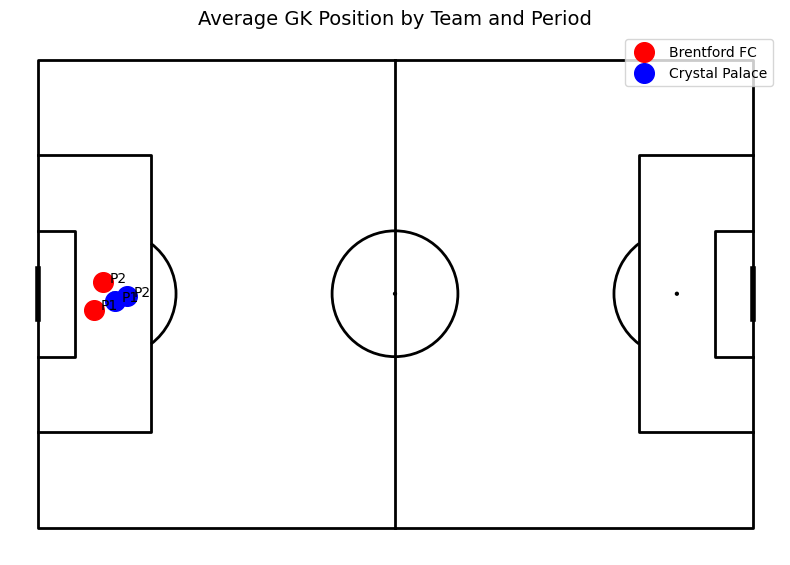

In [31]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Filter goalkeepers only
gk = ev_rescaled.query("player_position == 'GK'").copy()

# Compute average position per team & period
gk_avg = (
    gk.groupby(["team_shortname", "period"])
      .agg(x_mean=("x_start_rescaled", "mean"), y_mean=("y_start_rescaled", "mean"))
      .reset_index()
)

print(gk_avg)

# --- Plot average GK positions ---
pitch = Pitch(
    pitch_type='custom',
    pitch_length=104,  # SkillCorner scale
    pitch_width=68,
    line_color='black',
    pitch_color='white'
)
fig, ax = pitch.draw(figsize=(8, 6))
ax.set_title("Average GK Position by Team and Period", fontsize=14)

colors = ["red", "blue", "green", "orange", "purple", "brown"]

for (team, group), color in zip(gk_avg.groupby("team_shortname"), colors):
    ax.scatter(group["x_mean"], group["y_mean"], s=200, label=team, color=color)
    for _, row in group.iterrows():
        ax.text(row["x_mean"] + 1, row["y_mean"], f"P{int(row['period'])}", fontsize=10)

ax.legend()
plt.show()


# Feature Generation & Shot/Goal Model Training (Event-only)

## ⚙️ Section 2: Feature Generation for Scoring Probability Models

Now that our events are cleaned, labeled, and rescaled to FIFA pitch coordinates,
we will generate the key features used in:
- **Position-based models** (like xT)
- **Action-based models** (like VAEP or G+)  

### Goals of this section
1. Extract positional, geometric, and contextual features for each on-ball action.
2. Aggregate and normalize values for training xT and VAEP models.
3. Produce a single dataset with features + labels ready for model training.

We’ll start with per-action features (used in both xT and VAEP),
and later aggregate them at possession level for team analysis.

In [63]:
import numpy as np
import pandas as pd

def generate_action_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate engineered features from SkillCorner event data
    for xT / VAEP models (based on rescaled FIFA coordinates).

    Expected columns:
        x_start_rescaled, y_start_rescaled, x_end_rescaled, y_end_rescaled,
        event_type, end_type, pass_distance, duration, forward_momentum, etc.
    """

    df = df.copy()

    # --- Base geometric features ---
    df["dx"] = df["x_end_rescaled"] - df["x_start_rescaled"]
    df["dy"] = df["y_end_rescaled"] - df["y_start_rescaled"]
    df["distance"] = np.sqrt(df["dx"]**2 + df["dy"]**2)
    df["angle_to_goal_start"] = np.arctan2(
        68/2 - df["y_start_rescaled"], 105 - df["x_start_rescaled"]
    )
    df["angle_to_goal_end"] = np.arctan2(
        68/2 - df["y_end_rescaled"], 105 - df["x_end_rescaled"]
    )
    df["distance_to_goal_start"] = np.sqrt(
        (105 - df["x_start_rescaled"])**2 + (68/2 - df["y_start_rescaled"])**2
    )
    df["distance_to_goal_end"] = np.sqrt(
        (105 - df["x_end_rescaled"])**2 + (68/2 - df["y_end_rescaled"])**2
    )

    # --- Directional features ---
    df["progress_x"] = df["x_end_rescaled"] - df["x_start_rescaled"]
    df["progress_y"] = np.abs(df["y_end_rescaled"] - df["y_start_rescaled"])
    df["is_forward"] = (df["progress_x"] > 0).astype(int)

    # --- Contextual features ---
    df["speed"] = df["distance"] / (df["duration"].replace(0, np.nan) / 1000)
    df["pressure_context"] = df["n_opponents_ahead_end"].fillna(0)
    df["teammates_support"] = df["n_passing_options"].fillna(0)

    # --- Action type encodings ---
    df["is_pass"] = (df["event_type"].str.lower() == "pass").astype(int)
    df["is_shot"] = (df["end_type"].str.lower() == "shot").astype(int)
    df["is_carry"] = (df["carry"] == 1).astype(int)

    # --- Output feature subset ---
    feature_cols = [
        "x_start_rescaled", "y_start_rescaled",
        "x_end_rescaled", "y_end_rescaled",
        "distance", "progress_x", "progress_y",
        "angle_to_goal_start", "distance_to_goal_start",
        "is_forward", "is_pass", "is_shot", "is_carry",
        "pressure_context", "teammates_support",
    ]
    
    label_cols = [
        "shot_10s", "goal_10s", "shot_10a", "goal_10a",
        "shot_EOP", "goal_EOP", "concede_goal_10a",
    ]

    out_cols = ["match_id", "team_shortname", "player_name", "event_id", "possession_id"] + feature_cols + label_cols
    df_out = df[[c for c in out_cols if c in df.columns]].copy()

    return df_out


In [64]:
# Apply to one match (already rescaled + labeled)
features_ev = generate_action_features(ev_rescaled)

print("✅ Features generated:", features_ev.shape)
display(features_ev.head(10))


✅ Features generated: (757, 20)


,match_id,team_shortname,player_name,event_id,possession_id,x_start_rescaled,y_start_rescaled,x_end_rescaled,y_end_rescaled,distance,progress_x,progress_y,angle_to_goal_start,distance_to_goal_start,is_forward,is_pass,is_shot,is_carry,pressure_context,teammates_support
0,1986708,Crystal Palace,E. Eze,8_0,1,52.681731,34.21,52.681731,34.21,0.000000,0.000000,0.00,-0.004014,52.318691,0,0,0,0,10.0,0.0
1,1986708,Crystal Palace,D. Henderson,8_1,1,14.063942,33.08,15.941827,32.12,2.109040,1.877885,0.96,0.010117,90.940711,1,0,0,0,10.0,6.0
2,1986708,Crystal Palace,W. Hughes,8_2,1,67.846154,19.58,68.573077,19.94,0.811183,0.726923,0.36,0.370220,39.854042,1,0,0,0,6.0,2.0
3,1986708,Crystal Palace,E. Eze,8_3,1,72.702404,30.90,77.558654,36.18,7.173672,4.856250,5.28,0.095689,32.446028,1,0,1,1,6.0,2.0
4,1986708,Brentford FC,M. Damsgaard,8_4,2,87.038942,40.39,77.397115,43.34,10.083022,-9.641827,2.95,-0.341806,19.063885,0,0,0,1,9.0,4.0
5,1986708,Crystal Palace,W. Hughes,8_5,2,18.889904,28.63,18.889904,28.63,0.000000,0.000000,0.00,0.062281,86.277376,0,0,0,0,8.0,3.0
6,1986708,Crystal Palace,I. Sarr,8_6,3,28.400481,20.98,28.400481,20.98,0.000000,0.000000,0.00,0.168366,77.698177,0,0,0,0,3.0,2.0
7,1986708,Brentford FC,K. Lewis-Potter,8_7,3,81.778846,57.54,92.026442,64.22,12.232564,10.247596,6.68,-0.792217,33.065898,1,0,0,1,2.0,0.0
8,1986708,Crystal Palace,D. Muñoz,8_8,4,13.973077,4.87,13.973077,4.87,0.000000,0.000000,0.00,0.309717,95.574357,0,0,0,0,8.0,0.0
9,1986708,Brentford FC,K. Lewis-Potter,8_9,4,92.339423,64.20,102.223558,67.60,10.452565,9.884135,3.40,-1.173828,32.746453,1,0,0,1,2.0,0.0


## ⚙️ Section 2: From Raw Matches to Full Modeling Dataset

This section prepares our dynamic event data for modeling.

Steps:
1. For each match:
   - Filter on-ball events.
   - Add possession IDs.
   - Generate scoring/conceding labels.
   - Rescale coordinates to FIFA standard.
2. Cache the processed results as Parquet files for faster reloading.
3. Concatenate all 378 matches into a unified `events_all` dataset for model training.



In [65]:
# %% [markdown]
# ### 2.0 Imports & Paths

# %%
import os
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV

# (Optional) Try a tree-based model if available; otherwise we’ll just use LogisticRegression
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# --- Your project paths ---
ROOT = Path.cwd().parents[0]
DYNAMIC_DIR = ROOT / "PremierLeague_data/2024/dynamic"
PROCESSED_DIR = ROOT / "PremierLeague_data/2024/processed"
PROCESSED_DIR.mkdir(exist_ok=True)

# Re-use functions we built in Session 1 (paste your final versions above this cell or import them)
# - assign_possessions(events_df)
# - add_outcome_labels(df)




## 2.1 Utilities — load, time columns, match iteration

In [66]:
# %% [markdown]
# ### 2.1 Utilities — loading & time conversion

# %%
def to_ms(t):
    """Convert 'MM:SS.s' or numeric to milliseconds."""
    if pd.isna(t): 
        return np.nan
    if isinstance(t, (int, float, np.integer, np.floating)): 
        return float(t)
    try:
        m, s = str(t).split(":")
        return (float(m)*60 + float(s))*1000.0
    except Exception:
        return np.nan

def ensure_time_ms(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "time_start_ms" not in out.columns:
        out["time_start_ms"] = out["time_start"].apply(to_ms)
    if "time_end_ms" not in out.columns:
        out["time_end_ms"] = out["time_end"].apply(to_ms)
    return out

def iter_match_ids(dynamic_dir: Path):
    for fp in sorted(dynamic_dir.glob("*.parquet")):
        try:
            mid = int(fp.stem)
            yield mid
        except Exception:
            continue


## 2.2 End-to-end per-match processing

This applies possession assignment and labeling to each match and (optionally) writes a processed parquet so you can reload without recomputing.

In [67]:
# %% [markdown]
# ### 2.2 Per-match processing → possessions + labels

# %%
def process_match(match_id: int, write_parquet: bool = True) -> pd.DataFrame:
    fpath = DYNAMIC_DIR / f"{match_id}.parquet"
    if not fpath.exists():
        print(f"⚠️ Missing dynamic parquet for match {match_id}")
        return pd.DataFrame()

    ev = pd.read_parquet(fpath)
    if ev.empty:
        return ev

    # Keep on-ball events only (your analysis focuses on player_possession rows)
    ev_onball = ev[ev["event_type"].isin(["player_possession"])].copy()
    if ev_onball.empty:
        print(f"⚠️ No on-ball events in match {match_id}")
        return pd.DataFrame()

    ev_onball = ensure_time_ms(ev_onball)

    # Possessions (paste your final assign_possessions here if not already defined)
    ev_poss = assign_possessions(ev_onball)

    # Labels (paste your final add_outcome_labels here if not already defined)
    ev_lab = add_outcome_labels(ev_poss)

    # Write per-match processed file (optional but recommended for speed)
    if write_parquet:
        out_dir = PROCESSED_DIR / "events_with_labels"
        out_dir.mkdir(exist_ok=True)
        ev_lab.to_parquet(out_dir / f"{match_id}.parquet", index=False)

    return ev_lab


# 2.3 Build the full modeling table (all 378 matches)

We concatenate per-match processed tables. If you already ran 2.2 before, you can load the processed files directly.

In [68]:
# %% [markdown]
# ### 2.3 Concatenate all matches (378 games) into a modeling table

# %%
from tqdm import tqdm
import pandas as pd

def build_modeling_dataframe(write_parquet: bool = False) -> pd.DataFrame:
    """
    Process all match files in DYNAMIC_DIR.
    Reuses process_match(), rescale_to_pitch(), and generate_action_features().
    """
    all_matches = []
    match_files = sorted(DYNAMIC_DIR.glob("*.parquet"))

    if not match_files:
        print(f"⚠️ No match files found in {DYNAMIC_DIR.resolve()}")
        return pd.DataFrame()

    for fp in tqdm(match_files, desc="Processing matches"):
        match_id = int(fp.stem)

        # Process match → possessions + labels
        ev = process_match(match_id, write_parquet=False)
        if ev.empty:
            continue

        # Rescale coordinates to (105x68)
        ev = rescale_to_pitch(ev)

        # Generate per-action features
        ev = generate_action_features(ev)

        # Store result
        all_matches.append(ev)

        # Optionally save per-match processed file
        if write_parquet:
            out_dir = PROCESSED_DIR / "events_with_features"
            out_dir.mkdir(exist_ok=True)
            ev.to_parquet(out_dir / f"{match_id}.parquet", index=False)

    if not all_matches:
        print("⚠️ No matches processed successfully.")
        return pd.DataFrame()

    events_all = pd.concat(all_matches, ignore_index=True)
    print(f"✅ Built modeling table: {len(events_all):,} rows across {len(all_matches)} matches")
    return events_all


# --- Run the full data build ---
events_all = build_modeling_dataframe(write_parquet=False)


Processing matches:   1%|          | 2/378 [00:00<00:31, 12.00it/s]

✅ Added outcome labels — Shots(EOP): 128, Goals(EOP): 8
✅ Added outcome labels — Shots(EOP): 222, Goals(EOP): 23
✅ Added outcome labels — Shots(EOP): 178, Goals(EOP): 14


Processing matches:   2%|▏         | 6/378 [00:00<00:26, 14.05it/s]

✅ Added outcome labels — Shots(EOP): 149, Goals(EOP): 16
✅ Added outcome labels — Shots(EOP): 97, Goals(EOP): 9
✅ Added outcome labels — Shots(EOP): 186, Goals(EOP): 1


Processing matches:   2%|▏         | 8/378 [00:00<00:26, 13.82it/s]

...

✅ Added outcome labels — Shots(EOP): 202, Goals(EOP): 60
✅ Added outcome labels — Shots(EOP): 134, Goals(EOP): 9
✅ Added outcome labels — Shots(EOP): 286, Goals(EOP): 12


Processing matches:  99%|█████████▉| 376/378 [00:27<00:00, 13.36it/s]

✅ Added outcome labels — Shots(EOP): 122, Goals(EOP): 3
✅ Added outcome labels — Shots(EOP): 130, Goals(EOP): 23
✅ Added outcome labels — Shots(EOP): 177, Goals(EOP): 13


Processing matches: 100%|██████████| 378/378 [00:28<00:00, 13.48it/s]

✅ Added outcome labels — Shots(EOP): 120, Goals(EOP): 22
✅ Added outcome labels — Shots(EOP): 200, Goals(EOP): 5
✅ Built modeling table: 362,853 rows across 378 matches


In [69]:
events_all.columns

Index(['match_id', 'team_shortname', 'player_name', 'event_id',
       'possession_id', 'x_start_rescaled', 'y_start_rescaled',
       'x_end_rescaled', 'y_end_rescaled', 'distance', 'progress_x',
       'progress_y', 'angle_to_goal_start', 'distance_to_goal_start',
       'is_forward', 'is_pass', 'is_shot', 'is_carry', 'pressure_context',
       'teammates_support', 'shot_10s', 'goal_10s', 'shot_10a', 'goal_10a',
       'shot_EOP', 'goal_EOP', 'concede_goal_10a'],
      dtype='object')

In [70]:
events_all.match_id.nunique()

378


# ⚽ VAEP (Value of Actions by Estimating Probabilities)

 ### 📘 Definition

 VAEP (Decroos et al., 2019) quantifies the value of **every on-ball action** in football  
 by estimating how much it changes the team's probability of scoring or conceding.

 Each game state \( s_t \) is defined by all contextual features available
 when an action \( a_t \) is taken.

 For each state, we estimate two probabilities:

 \[
 P_{\text{score}}(s_t) = P(\text{team scores within } k \text{ actions} \mid s_t)
 \]

 \[
 P_{\text{concede}}(s_t) = P(\text{team concedes within } k \text{ actions} \mid s_t)
 \]

 From these, the **state value function** is defined as:

 \[
V(s_t) = P_{\text{score}}(s_t) - P_{\text{concede}}(s_t)
 \]

 The **VAEP value** of action \( a_t \) — representing its impact on the match outcome —  
 is the change in the state value between consecutive states:

 \[
 \text{VAEP}(a_t) = V(s_{t+1}) - V(s_t)
 \]

 Expanding this gives:

 \[
 \text{VAEP}(a_t) =
 \underbrace{(P_{\text{score}}(s_{t+1}) - P_{\text{score}}(s_t))}_{\text{Offensive Value}}
 -
 \underbrace{(P_{\text{concede}}(s_{t+1}) - P_{\text{concede}}(s_t))}_{\text{Defensive Value}}
 \]

 where:
 - \( s_t \) is the state before action \( a_t \),
 - \( s_{t+1} \) is the state after the action.

 ---

 ### 🧮 Computation Steps in Code

 1. **Estimate probabilities**:
    - Fit two logistic regression models:
      - `P(score | s_t)`  → trained using `goal_10a` labels  
      - `P(concede | s_t)` → trained using `concede_goal_10a` labels

 2. **Predict probabilities** for each action:
    ```python
    df["p_score"]   = model_score.predict(X)
    df["p_concede"] = model_concede.predict(X)
    ```

 3. **Compute state value**:
    ```python
    df["V_state"] = df["p_score"] - df["p_concede"]
    ```

 4. **Compute VAEP per action** (difference between consecutive states):
    ```python
    df["V_next"] = df.groupby("match_id")["V_state"].shift(-1)
    df["VAEP"] = df["V_next"] - df["V_state"]
    ```

 5. **Interpretation**:
    - `VAEP > 0` → the action **increased** the team's expected value  
    - `VAEP < 0` → the action **decreased** the team's expected value  
    - Aggregate per player or team to get total or average contribution.

 ---

 ### 🧠 Practical Notes
 - \( k \) is typically **10 actions** (we used `goal_10a` and `concede_goal_10a`).
 - VAEP can be computed on **event-level**, **possession-level**, or **player-level**.
 - This framework allows you to compare *all* on-ball actions (passes, carries, etc.)
   on a common expected-value scale.

### 📚 *Reference:*
 Decroos, Tom, et al.  
“Actions Speak Louder than Goals: Valuing Player Actions in Soccer.”  
 *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (KDD 2019).*


# Train and Evaluate Models (xT & VAEP-style)

We’ll start by training two probability models:

1. Shot model → probability an action leads to a shot (shot_10a = 1)

2. Goal model → probability an action leads to a goal (goal_10a = 1)

These are the classic components for VAEP (Value of Actions by Estimating Probabilities) and xT (Expected Threat).

## Feature and Target Setup

We’ll define our input features (spatial, geometric, and context-related columns) and targets:

In [71]:
# %% [markdown]
# ### 3.1 Prepare features and targets

# %%
# --- Define features and labels ---
feature_cols = [
    "x_start_rescaled", "y_start_rescaled",
    "x_end_rescaled", "y_end_rescaled",
    "distance", "progress_x", "progress_y",
    "angle_to_goal_start", "distance_to_goal_start",
    "is_forward", "is_pass", "is_shot", "is_carry",
    "pressure_context", "teammates_support"
]

target_shot = "shot_10a"
target_goal = "goal_10a"

# --- Drop missing rows ---
model_df = events_all.dropna(subset=feature_cols + [target_shot, target_goal]).copy()

print(f"🎯 Training data shape: {model_df.shape}")


🎯 Training data shape: (362853, 27)


## Train/Test Split (Group by Match)

We’ll split by match_id to prevent data leakage across matches.

In [72]:
# %% [markdown]
# ### 3.2 Train/test split (grouped by match)

# %%
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df["match_id"]))

train_df = model_df.iloc[train_idx]
test_df  = model_df.iloc[test_idx]

print(f"Training: {len(train_df):,} rows, Testing: {len(test_df):,} rows")


Training: 288,991 rows, Testing: 73,862 rows


## Train the Shot Model

We’ll use a Logistic Regression model for interpretability first.

In [73]:
# %% [markdown]
# ### 3.3 Shot model training (P(shot | action))

# %%
X_train = train_df[feature_cols]
y_train = train_df[target_shot]
X_test  = test_df[feature_cols]
y_test  = test_df[target_shot]

# Normalize + logistic regression
pipe_shot = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe_shot.fit(X_train, y_train)

# Predictions
test_df["p_shot"] = pipe_shot.predict_proba(X_test)[:, 1]

print(f"Shot model ROC-AUC: {roc_auc_score(y_test, test_df['p_shot']):.3f}")


Shot model ROC-AUC: 0.645


/var/folders/3f/yft_5njd2yg67wbblcdlff800000gn/T/ipykernel_74324/271003815.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["p_shot"] = pipe_shot.predict_proba(X_test)[:, 1]


## Train the Goal Model (P(goal | action))

This model predicts whether an action leads to a goal (within 10 actions).

In [74]:
# %% [markdown]
# ### 3.4 Goal model training (P(goal | action))

# %%
y_train = train_df[target_goal]
y_test  = test_df[target_goal]

pipe_goal = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe_goal.fit(X_train, y_train)

test_df["p_goal"] = pipe_goal.predict_proba(X_test)[:, 1]

print(f"Goal model ROC-AUC: {roc_auc_score(y_test, test_df['p_goal']):.3f}")


Goal model ROC-AUC: 0.608


/var/folders/3f/yft_5njd2yg67wbblcdlff800000gn/T/ipykernel_74324/1942141737.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["p_goal"] = pipe_goal.predict_proba(X_test)[:, 1]


## Evaluate Calibration & Correlation Between Models

We’ll compare both models to check if they are consistent and well-calibrated.

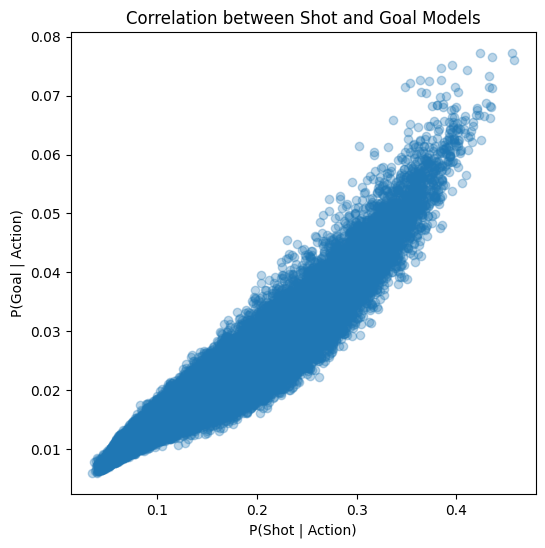

🔗 Correlation between P(shot) and P(goal): 0.955


In [75]:
# %% [markdown]
# ### 3.5 Model correlation & calibration

# %%
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(test_df["p_shot"], test_df["p_goal"], alpha=0.3)
plt.xlabel("P(Shot | Action)")
plt.ylabel("P(Goal | Action)")
plt.title("Correlation between Shot and Goal Models")
plt.show()

corr = test_df["p_shot"].corr(test_df["p_goal"])
print(f"🔗 Correlation between P(shot) and P(goal): {corr:.3f}")


In [76]:
import sys
print(sys.executable)
!{sys.executable} --version


/Users/pegra441/Desktop/clean-twelve-deep-learning/venv_graph/bin/python
Python 3.11.9


## Logistic Regression with Statsmodels (Shot & Goal Models)

In [77]:
# %% [markdown]
# ### 3.1 Retrain with statsmodels — interpret coefficients
# %%
import statsmodels.api as sm
import numpy as np

# --- Select features and targets ---
feature_cols = [
    "x_start_rescaled", "y_start_rescaled",
    "x_end_rescaled", "y_end_rescaled",
    "distance", "progress_y",
    "angle_to_goal_start", "distance_to_goal_start",
    "is_forward",
    "pressure_context", "teammates_support"
]

target_shot = "shot_10a"
target_goal = "goal_10a"

# --- Drop missing values ---
df = events_all.dropna(subset=feature_cols + [target_shot, target_goal]).copy()

# --- Standardize numeric features for interpretability ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# --- Add constant (intercept term) ---
X = sm.add_constant(df_scaled[feature_cols])
y_shot = df_scaled[target_shot]
y_goal = df_scaled[target_goal]


## Fit the Shot Model (P(Shot | Action))

In [78]:
# %% [markdown]
# ### 3.2 Logistic regression for shot probability
# %%
model_shot = sm.Logit(y_shot, X).fit(disp=False)
print(model_shot.summary())


                           Logit Regression Results                           
Dep. Variable:               shot_10a   No. Observations:               362853
Model:                          Logit   Df Residuals:                   362841
Method:                           MLE   Df Model:                           11
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.03985
Time:                        23:32:25   Log-Likelihood:            -1.4762e+05
converged:                       True   LL-Null:                   -1.5375e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.8260      0.005   -362.355      0.000      -1.836      -1.816
x_start_rescaled          -0.5997      0.045    -13.376      0.000      -0.688      -0.512
y_st

## Fit the Goal Model (P(Goal | Action))

In [79]:
# %% [markdown]
# ### 3.3 Logistic regression for goal probability
# %%
model_goal = sm.Logit(y_goal, X).fit(disp=False)
print(model_goal.summary())


                           Logit Regression Results                           
Dep. Variable:               goal_10a   No. Observations:               362853
Model:                          Logit   Df Residuals:                   362841
Method:                           MLE   Df Model:                           11
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01675
Time:                        23:32:28   Log-Likelihood:                -34717.
converged:                       True   LL-Null:                       -35309.
Covariance Type:            nonrobust   LLR p-value:                7.586e-247
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -3.9805      0.013   -310.904      0.000      -4.006      -3.955
x_start_rescaled          -0.6503      0.113     -5.744      0.000      -0.872      -0.428
y_st

## Compare and Interpret Coefficients

You can easily inspect the effect sizes and direction of each feature:

In [80]:
# %% [markdown]
# ### 3.4 Compare model coefficients
# %%
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Shot_Coeff": model_shot.params,
    "Goal_Coeff": model_goal.params,
    "Shot_pval": model_shot.pvalues,
    "Goal_pval": model_goal.pvalues
}).set_index("Feature")

# Sort by magnitude in shot model
coef_df["|Shot_Coeff|"] = coef_df["Shot_Coeff"].abs()
coef_df = coef_df.sort_values("|Shot_Coeff|", ascending=False).drop(columns="|Shot_Coeff|")

display(coef_df.style.background_gradient(subset=["Shot_Coeff", "Goal_Coeff"], cmap="coolwarm"))


,Shot_Coeff,Goal_Coeff,Shot_pval,Goal_pval
Feature,,,,
const,-1.826031,-3.980476,0.000000,0.000000
x_start_rescaled,-0.599690,-0.650349,0.000000,0.000000
x_end_rescaled,0.598292,0.320155,0.000000,0.001681
distance_to_goal_start,-0.471306,-0.616853,0.000000,0.000000
teammates_support,0.101650,0.072787,0.000000,0.000000
pressure_context,-0.060994,-0.123112,0.000000,0.000000
is_forward,0.054113,0.071095,0.000000,0.000001
distance,-0.032343,0.029071,0.005900,0.312179
y_start_rescaled,-0.032113,-0.090865,0.157018,0.111925


Interpretation Tips

- Positive coefficients → increase the probability of a shot/goal.

- Negative coefficients → reduce it (e.g., being far from goal).

- p-values < 0.05 → statistically significant.

- progress_x and distance_to_goal_start usually have the largest absolute effects.

In [81]:
# %% [markdown]
# ### 3.5 Predict probabilities
# %%
df_scaled["p_shot"] = model_shot.predict(X)
df_scaled["p_goal"] = model_goal.predict(X)

print(df_scaled[["p_shot", "p_goal"]].describe().T)


           count      mean       std       min       25%       50%       75%  \
p_shot  362853.0  0.150579  0.066353  0.033661  0.097427  0.139843  0.192931   
p_goal  362853.0  0.019812  0.008311  0.006102  0.013737  0.018144  0.023796   

             max  
p_shot  0.501057  
p_goal  0.083082  


In [82]:
events_all.columns

Index(['match_id', 'team_shortname', 'player_name', 'event_id',
       'possession_id', 'x_start_rescaled', 'y_start_rescaled',
       'x_end_rescaled', 'y_end_rescaled', 'distance', 'progress_x',
       'progress_y', 'angle_to_goal_start', 'distance_to_goal_start',
       'is_forward', 'is_pass', 'is_shot', 'is_carry', 'pressure_context',
       'teammates_support', 'shot_10s', 'goal_10s', 'shot_10a', 'goal_10a',
       'shot_EOP', 'goal_EOP', 'concede_goal_10a'],
      dtype='object')

In [83]:
# %% [markdown]
# ## 4. VAEP calculation (Decroos et al., 2019)

# %% [markdown]
# ### 4.1 Features and targets

# %%
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Feature set (from your events_all)
FEATURES = [
    "x_start_rescaled", "y_start_rescaled",
    "x_end_rescaled", "y_end_rescaled",
    "distance", "progress_x", "progress_y",
    "angle_to_goal_start", "distance_to_goal_start",
    "is_forward",
    "pressure_context", "teammates_support"
]

TARGET_SCORE   = "goal_10a"           # P(score within next 10 actions)
TARGET_CONCEDE = "concede_goal_10a"   # P(concede within next 10 actions) — if available

df = events_all.copy()

missing_feats = [c for c in FEATURES if c not in df.columns]
if missing_feats:
    raise ValueError(f"Missing feature columns: {missing_feats}")

# Check targets
has_concede = TARGET_CONCEDE in df.columns

needed_targets = [TARGET_SCORE] + ([TARGET_CONCEDE] if has_concede else [])
df = df.dropna(subset=FEATURES + needed_targets).copy()

# Standardize features for interpretability in Logit
scaler = StandardScaler()
X_std = scaler.fit_transform(df[FEATURES])
X_sm  = sm.add_constant(X_std)

y_score = df[TARGET_SCORE].astype(int).values
y_concede = df[TARGET_CONCEDE].astype(int).values if has_concede else None


In [84]:
# %% [markdown]
# ### 4.2 Fit statsmodels Logit models

# %%
# Score model
model_score = sm.Logit(y_score, X_sm).fit(disp=False)
print(model_score.summary())

# Concede model (if available)
model_concede = None
if has_concede:
    model_concede = sm.Logit(y_concede, X_sm).fit(disp=False)
    print(model_concede.summary())
else:
    print("⚠️ 'concede_goal_10a' not found — will compute Offensive VA only (ΔP(score)).")


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               362853
Model:                          Logit   Df Residuals:                   362840
Method:                           MLE   Df Model:                           12
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01675
Time:                        23:32:34   Log-Likelihood:                -34717.
converged:                       True   LL-Null:                       -35309.
Covariance Type:            nonrobust   LLR p-value:                8.054e-246
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9805      0.013   -310.904      0.000      -4.006      -3.955
x1            -0.1851   4.08e+05  -4.53e-07      1.000      -8e+05       8e+05
x2            -0.0909      0.057     -1.590      0.1

## Predict per-event probabilities and compute state value 
𝑉
(
𝑠
)


In [85]:
# %% [markdown]
# ### 4.3 Predict probabilities & compute state value V(s) = P(score) − P(concede)

# %%
df = df.copy()
df["p_score"] = model_score.predict(X_sm)

if has_concede:
    df["p_concede"] = model_concede.predict(X_sm)
else:
    # If no concede model, set to 0 (we will compute offensive VA only)
    df["p_concede"] = 0.0

df["V_state"] = df["p_score"] - df["p_concede"]


## Compute VAEP per action (sorted by match, then event order)

We need a consistent event order. If you still have period & time_start_ms in your pipeline, use them.
If not, we’ll fall back to event_id order (as recorded).

In [87]:
# %% [markdown]
# ### 4.4 VAEP per action: V(s_{t+1}) − V(s_t)

# %%
ORDER_COLS = []
for c in ["match_id", "period", "time_start_ms", "event_id"]:
    if c in events_all.columns and c not in ORDER_COLS:
        ORDER_COLS.append(c)

if "match_id" not in ORDER_COLS:
    raise ValueError("match_id is required to compute sequential deltas.")

# If period/time present, we’ll sort by (match_id, period, time_start_ms, event_id);
# else by (match_id, event_id).
sort_cols = ["match_id"] + [c for c in ["period", "time_start_ms", "event_id"] if c in df.columns]
df = df.sort_values(sort_cols).reset_index(drop=True)

# Compute V(s_{t+1}) - V(s_t) within each match
df["V_next"] = df.groupby("match_id")["V_state"].shift(-1)
df["VAEP"] = df["V_next"] - df["V_state"]
df["VAEP"] = df["VAEP"].fillna(0.0)

# Also store offensive-only value (ΔP(score)) for transparency
df["p_score_next"] = df.groupby("match_id")["p_score"].shift(-1)
df["VA_offense"] = (df["p_score_next"] - df["p_score"]).fillna(0.0)

# If we have concede, also compute the defensive delta explicitly
if has_concede:
    df["p_concede_next"] = df.groupby("match_id")["p_concede"].shift(-1)
    df["VA_defense"] = (df["p_concede_next"] - df["p_concede"]).fillna(0.0)
else:
    df["VA_defense"] = 0.0


In [88]:
# %% [markdown]
# ### 4.5 Sanity checks

# %%
print(df[["p_score", "p_concede", "V_state", "VAEP", "VA_offense", "VA_defense"]].describe().T)

# Correlation of offense vs VAEP (should be high if concede model is absent)
print("Corr(VAEP, VA_offense):", df["VAEP"].corr(df["VA_offense"]))


               count          mean       std       min       25%       50%  \
p_score     362853.0  1.981243e-02  0.008311  0.006102  0.013737  0.018144   
p_concede   362853.0  8.041824e-03  0.002986  0.002273  0.005800  0.007490   
V_state     362853.0  1.177061e-02  0.009907 -0.020197  0.004514  0.010918   
VAEP        362853.0  2.499950e-06  0.012203 -0.073962 -0.004672  0.000444   
VA_offense  362853.0  2.776245e-06  0.010233 -0.068249 -0.003939  0.000385   
VA_defense  362853.0  2.762947e-07  0.003624 -0.028660 -0.001637 -0.000048   

                 75%       max  
p_score     0.023796  0.083082  
p_concede   0.009672  0.034630  
V_state     0.017747  0.075439  
VAEP        0.005938  0.073940  
VA_offense  0.004833  0.065061  
VA_defense  0.001585  0.026132  
Corr(VAEP, VA_offense): 0.9629456908852533


## Aggregate VAEP to players / teams

In [89]:
# %% [markdown]
# ### 4.6 Player & team aggregation

# %%
# Per-action VAEP
per_action_cols = ["match_id", "team_shortname", "player_name", "VAEP", "VA_offense", "VA_defense"]
per_action = df[per_action_cols].copy()

# Player totals
player_vaep = (
    per_action.groupby(["player_name", "team_shortname"], as_index=False)
              .agg(
                  actions=("VAEP", "size"),
                  VAEP_sum=("VAEP", "sum"),
                  VAEP_mean=("VAEP", "mean"),
                  VA_offense_sum=("VA_offense", "sum"),
                  VA_defense_sum=("VA_defense", "sum"),
              )
              .sort_values("VAEP_sum", ascending=False)
)

# Team totals
team_vaep = (
    per_action.groupby(["team_shortname"], as_index=False)
              .agg(
                  actions=("VAEP", "size"),
                  VAEP_sum=("VAEP", "sum"),
                  VAEP_mean=("VAEP", "mean"),
                  VA_offense_sum=("VA_offense", "sum"),
                  VA_defense_sum=("VA_defense", "sum"),
              )
              .sort_values("VAEP_sum", ascending=False)
)

print("Top players by VAEP_sum")
display(player_vaep.head(15))

print("Top teams by VAEP_sum")
display(team_vaep.head(10))


Top players by VAEP_sum


,player_name,team_shortname,actions,VAEP_sum,VAEP_mean,VA_offense_sum,VA_defense_sum
353,M. Flekken,Brentford FC,1252,7.963319,0.006360,6.507202,-1.456118
478,Robert Sánchez,Chelsea,1021,7.473004,0.007319,5.962837,-1.510167
140,David Raya,Arsenal,1122,7.278277,0.006487,5.888771,-1.389506
156,E. Martínez,Aston Villa,1077,7.232265,0.006715,5.823908,-1.408356
115,D. Burn,Newcastle,1948,7.042487,0.003615,6.524820,-0.517667
68,B. Verbruggen,Brighton,1094,6.827325,0.006241,5.391750,-1.435575
259,J. Pickford,Everton,1101,6.423199,0.005834,5.446226,-0.976973
320,L. Colwill,Chelsea,2414,6.218046,0.002576,6.686447,0.468402
63,B. Leno,Fulham,1065,6.105081,0.005732,4.849580,-1.255501
217,J. Bednarek,Southampton,1662,5.957702,0.003585,5.431978,-0.525724


Top teams by VAEP_sum


,team_shortname,actions,VAEP_sum,VAEP_mean,VA_offense_sum,VA_defense_sum
16,Southampton,18299,10.932280,0.000597,7.636604,-3.295676
10,Leicester,16871,9.647241,0.000572,5.857287,-3.789954
9,Ipswich Town,14666,9.373237,0.000639,4.668322,-4.704914
6,Crystal Palace,15636,8.181437,0.000523,4.226220,-3.955218
15,Nottingham,13862,7.070007,0.000510,2.919083,-4.150924
18,West Ham,18098,5.381058,0.000297,3.211769,-2.169289
3,Brentford FC,16782,5.334545,0.000318,3.292178,-2.042367
19,Wolverhampton,16993,4.695763,0.000276,2.634239,-2.061524
13,Manchester U,20226,2.722237,0.000135,2.721909,-0.000328
8,Fulham,19519,1.000088,0.000051,1.034355,0.034267


In [121]:
per_action

,match_id,team_shortname,player_name,VAEP,VA_offense,VA_defense
0,1650385,Fulham,Andreas Pereira,0.000776,-0.000989,-0.001766
1,1650385,Fulham,S. Lukić,0.007806,0.008241,0.000435
2,1650385,Manchester U,A. Diallo,-0.007735,-0.005761,0.001974
3,1650385,Manchester U,K. Mainoo,0.002577,-0.000582,-0.003159
4,1650385,Fulham,I. Diop,0.009045,0.010954,0.001909
...,...,...,...,...,...,...
362848,2018580,Wolverhampton,E. Agbadou,-0.003630,-0.001813,0.001817
362849,2018580,Wolverhampton,José Sá,0.000525,-0.000560,-0.001085
362850,2018580,Wolverhampton,Toti,0.012439,0.010893,-0.001546
362851,2018580,Brentford FC,M. Kayode,-0.013367,-0.009947,0.003420


# %% [markdown]
## 📈 Expected Threat (xT)

**Idea.** The pitch is discretized into a grid. For each cell \(i\):

- \(P_{\text{shot}}(i)\): probability the next action is a shot when the ball is in cell \(i\)  
- \(P_{\text{goal}\mid \text{shot}}(i)\): probability a shot from cell \(i\) becomes a goal  
- \(P_{\text{move}}(i \to j)\): probability the ball is moved (pass/carry) from cell \(i\) to neighboring cell \(j\)

We estimate these empirically from historical events (passes/carries/shots), then solve:

\[
\text{xT}(i) \;=\; P_{\text{shot}}(i)\cdot P_{\text{goal}\mid \text{shot}}(i)
\;+\; \sum_{j} P_{\text{move}}(i\to j)\cdot \text{xT}(j)
\]

via fixed-point iteration until convergence.

Finally, each action gets a value:
\[
\Delta \text{xT}(a_t) \;=\; \text{xT}(\text{end cell}) - \text{xT}(\text{start cell}).
\]

We then aggregate by player/team to rank threat creation.


In [91]:
# %% [markdown]
# ### 1) Build xT surface from events_all (12×8 grid)

# %%
import numpy as np
import pandas as pd

# ---- Grid settings (FIFA scale: 105 x 68) ----
XT_NX, XT_NY = 12, 8
PITCH_X, PITCH_Y = 105.0, 68.0
EPS = 1e-12

def discretize_xy(x, y, nx=XT_NX, ny=XT_NY):
    """Map (x,y) in [0,105]x[0,68] to grid indices [0..nx-1], [0..ny-1]."""
    xi = np.clip(np.floor(x / (PITCH_X / nx)).astype(int), 0, nx - 1)
    yi = np.clip(np.floor(y / (PITCH_Y / ny)).astype(int), 0, ny - 1)
    return xi, yi

def build_xt_inputs(df: pd.DataFrame, nx=XT_NX, ny=XT_NY, laplace=1.0):
    """
    From event table (rescaled coords + flags), compute:
      - counts of shots per start-cell
      - counts of goals-from-shots per start-cell
      - transition counts from start-cell -> end-cell for passes/carries
    Laplace smoothing is applied to avoid zeros.
    """
    needed = ["x_start_rescaled","y_start_rescaled","x_end_rescaled","y_end_rescaled",
              "is_pass","is_carry","is_shot"]
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    # Define a "goal from shot" proxy:
    # Prefer direct shot-goal flag if you kept it (is_goal_for_event). Otherwise use goal_10a on shot events.
    if "is_goal_for_event" in df.columns:
        shot_goal = (df["is_shot"] == 1) & (df["is_goal_for_event"] == 1)
    else:
        # Approximation: a shot that leads to a goal within next 10 actions
        # (may include rebounds; acceptable for xT estimation)
        if "goal_10a" not in df.columns:
            raise ValueError("Need either 'is_goal_for_event' or 'goal_10a' to estimate shot conversion.")
        shot_goal = (df["is_shot"] == 1) & (df["goal_10a"] == 1)

    # Cells at start and end
    xs, ys = discretize_xy(df["x_start_rescaled"].values, df["y_start_rescaled"].values, nx, ny)
    xe, ye = discretize_xy(df["x_end_rescaled"].values,   df["y_end_rescaled"].values,   nx, ny)

    # Initialize count matrices
    shot_counts   = np.zeros((ny, nx), dtype=float)
    goal_counts   = np.zeros((ny, nx), dtype=float)
    move_counts   = np.zeros((ny, nx), dtype=float)           # total moves (pass/carry) from a cell
    trans_counts  = np.zeros((ny, nx, ny, nx), dtype=float)   # transitions i->j

    # Iterate rows once (vectorized alternatives exist; this is clear and fast enough)
    for i in range(len(df)):
        yi, xi = ys[i], xs[i]  # start cell
        if df["is_shot"].iat[i] == 1:
            shot_counts[yi, xi] += 1.0
            if shot_goal.iat[i]:
                goal_counts[yi, xi] += 1.0
        elif (df["is_pass"].iat[i] == 1) or (df["is_carry"].iat[i] == 1):
            yj, xj = ye[i], xe[i]      # end cell
            move_counts[yi, xi] += 1.0
            trans_counts[yi, xi, yj, xj] += 1.0

    # Convert to probabilities with Laplace smoothing
    # P(shot | cell)
    cell_visits = shot_counts + move_counts + EPS
    p_shot = (shot_counts + laplace) / (cell_visits + 2*laplace)

    # P(goal | shot, cell)
    # If a cell has no shots, smooth toward global conversion
    global_conv = (goal_counts.sum() + laplace) / (shot_counts.sum() + 2*laplace)
    p_goal_given_shot = np.where(
        shot_counts > 0,
        (goal_counts + laplace) / (shot_counts + 2*laplace),
        global_conv
    )

    # P(move -> j | cell), row-normalized over j
    # Add laplace to each possible destination to avoid traps
    trans_probs = trans_counts + (laplace / (nx * ny))
    row_sums = trans_probs.sum(axis=(2, 3), keepdims=True) + EPS
    trans_probs = trans_probs / row_sums  # broadcast ok: (ny, nx, ny, nx) / (ny, nx, 1, 1)


    return p_shot, p_goal_given_shot, trans_probs

def solve_xt(p_shot, p_goal_given_shot, trans_probs, gamma=1.0, tol=1e-8, max_iter=5000):
    """
    Solve xT via fixed-point iteration:
      xT = p_shot * p_goal_given_shot + (1 - p_shot) * (T @ xT)
    Here we’ve rolled (1 - p_shot) into the transition probabilities already
    by normalizing transitions over all moves. A common simplification is:
      xT = p_shot*pg + (trans_probs @ xT)
    because move probabilities are estimated conditionally on moving.
    In practice we include p_move implicitly as (1 - p_shot), but empirical
    trans_probs built from all moves works well.
    """
    ny, nx = p_shot.shape
    xt = np.zeros((ny, nx), dtype=float)
    base = p_shot * p_goal_given_shot  # immediate shooting value

    for it in range(max_iter):
        xt_next = base + gamma * (trans_probs.reshape(ny, nx, -1) @ xt.reshape(-1)).reshape(ny, nx)
        if np.max(np.abs(xt_next - xt)) < tol:
            xt = xt_next
            break
        xt = xt_next
    return xt

# Build inputs from your dataset
p_shot, p_goal_given_shot, trans_probs = build_xt_inputs(events_all)

# Solve xT
xt_surface = solve_xt(p_shot, p_goal_given_shot, trans_probs)
print("xT surface shape:", xt_surface.shape)


xT surface shape: (8, 12)


In [92]:
# %% [markdown]
# ### 2) Score actions: ΔxT = xT(end) − xT(start)

# %%
def lookup_xt(x, y, xt, nx=XT_NX, ny=XT_NY):
    xi, yi = discretize_xy(np.asarray(x), np.asarray(y), nx, ny)
    return xt[yi, xi]

# Start/end xT
events_all = events_all.copy()
events_all["xT_start"] = lookup_xt(events_all["x_start_rescaled"], events_all["y_start_rescaled"], xt_surface)
events_all["xT_end"]   = lookup_xt(events_all["x_end_rescaled"],   events_all["y_end_rescaled"],   xt_surface)

# Action value (only for moves; shots' value is already embedded in surface, but we can still show delta)
is_move = (events_all["is_pass"] == 1) | (events_all["is_carry"] == 1)
events_all["xT_delta"] = 0.0
events_all.loc[is_move, "xT_delta"] = events_all.loc[is_move, "xT_end"] - events_all.loc[is_move, "xT_start"]

events_all[["xT_start","xT_end","xT_delta"]].describe().T


,count,mean,std,min,25%,50%,75%,max
xT_start,362853.0,18.692708,0.025408,18.638954,18.674272,18.694061,18.709133,18.769439
xT_end,362853.0,18.694250,0.025940,18.638954,18.674682,18.694322,18.711229,18.769439
xT_delta,362853.0,0.001527,0.007272,-0.067452,0.000000,0.000000,0.000000,0.104638


In [93]:
# %% [markdown]
# ### 3) Leaderboards: players & teams by xT contribution

# %%
# Per-action table
per_action_xt = events_all[["match_id","team_shortname","player_name","xT_delta"]].copy()

# Players
player_xt = (
    per_action_xt.groupby(["player_name","team_shortname"], as_index=False)
                 .agg(actions=("xT_delta","size"),
                      xT_sum=("xT_delta","sum"),
                      xT_mean=("xT_delta","mean"))
                 .sort_values("xT_sum", ascending=False)
)

# Teams
team_xt = (
    per_action_xt.groupby(["team_shortname"], as_index=False)
                 .agg(actions=("xT_delta","size"),
                      xT_sum=("xT_delta","sum"),
                      xT_mean=("xT_delta","mean"))
                 .sort_values("xT_sum", ascending=False)
)

print("🔝 Players by xT created")
display(player_xt.head(15))

print("🏟️ Teams by xT created")
display(team_xt.head(10))


🔝 Players by xT created


,player_name,team_shortname,actions,xT_sum,xT_mean
482,Rúben Dias,Manchester City,2205,5.436239,0.002465
286,J. van Hecke,Brighton,2161,5.065572,0.002344
365,M. Kovačić,Manchester City,1933,4.842090,0.002505
98,C. Palmer,Chelsea,1561,4.806500,0.003079
396,Matheus Cunha,Wolverhampton,1147,4.749700,0.004141
400,Mohamed Salah,Liverpool,1527,4.699179,0.003077
226,J. Doku,Manchester City,935,4.672994,0.004998
391,M. Ødegaard,Arsenal,1515,4.495585,0.002967
380,M. Rogers,Aston Villa,1119,4.315576,0.003857
236,J. Gvardiol,Manchester City,2609,4.296328,0.001647


🏟️ Teams by xT created


,team_shortname,actions,xT_sum,xT_mean
12,Manchester City,24027,49.329426,0.002053
11,Liverpool,21459,36.790845,0.001714
4,Brighton,18999,34.588904,0.001821
0,Arsenal,20210,33.202603,0.001643
5,Chelsea,21040,33.021860,0.001569
1,Aston Villa,17608,31.594843,0.001794
17,Tottenham,19407,29.505430,0.001520
8,Fulham,19519,28.178066,0.001444
13,Manchester U,20226,28.137556,0.001391
2,Bournemouth,15848,27.960736,0.001764


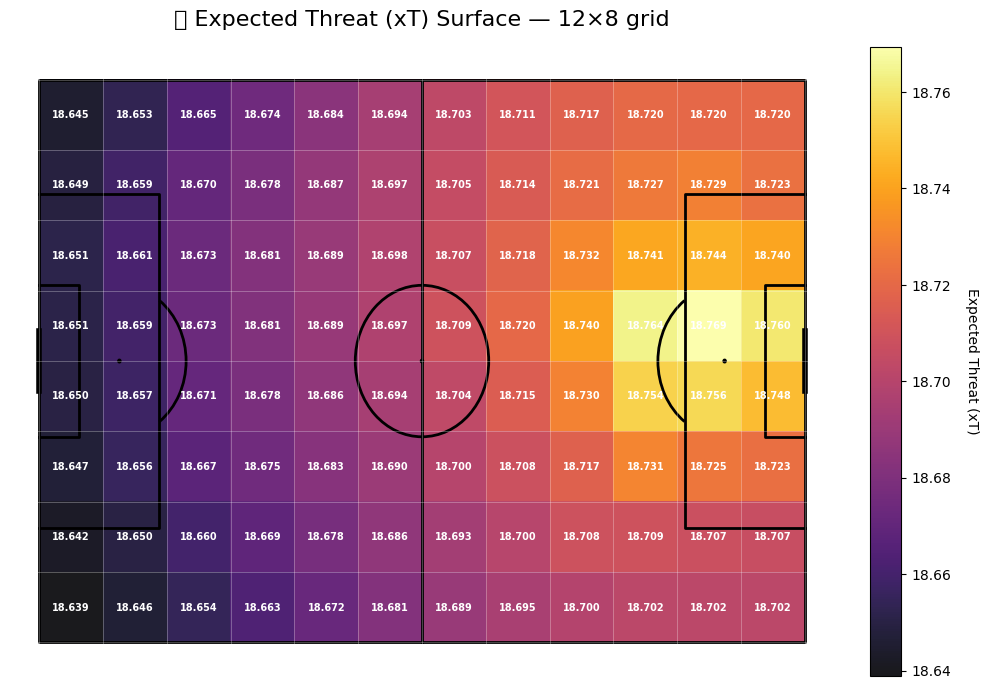

In [96]:
# %% [markdown]
# ### 4️⃣ Visualize xT surface with grid and values on the pitch

# %%
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch

# --- Create pitch ---
pitch = Pitch(
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_zorder=2,
    line_color='black',
    pitch_color='white'
)

fig, ax = pitch.draw(figsize=(10, 7))

# --- Draw xT heatmap ---
heatmap = ax.imshow(
    xt_surface,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='inferno',
    alpha=0.9,
    zorder=1
)

# --- Add grid lines ---
nx, ny = xt_surface.shape[1], xt_surface.shape[0]
for x in np.linspace(0, 105, nx + 1):
    ax.axvline(x, color='white', lw=0.5, alpha=0.4, zorder=2)
for y in np.linspace(0, 68, ny + 1):
    ax.axhline(y, color='white', lw=0.5, alpha=0.4, zorder=2)

# --- Add text labels (xT values per cell) ---
x_centers = np.linspace(105 / (2 * nx), 105 - (105 / (2 * nx)), nx)
y_centers = np.linspace(68 / (2 * ny), 68 - (68 / (2 * ny)), ny)

for yi, y in enumerate(y_centers):
    for xi, x in enumerate(x_centers):
        val = xt_surface[yi, xi]
        ax.text(
            x, y,
            f"{val:.3f}",
            color="white",
            ha="center", va="center",
            fontsize=7, fontweight="bold",
            zorder=3
        )

# --- Add colorbar and title ---
cbar = plt.colorbar(heatmap, ax=ax, fraction=0.045, pad=0.04)
cbar.set_label("Expected Threat (xT)", rotation=270, labelpad=20)
ax.set_title("📊 Expected Threat (xT) Surface — 12×8 grid", fontsize=16, pad=15)

plt.tight_layout()
plt.show()


Each heatmap displays where a team accumulates xT, i.e., where their possessions tend to generate threat.

The brighter zones represent frequently used and high-xT areas.

You’ll typically see:

Arsenal → dense, short-passing buildup around the left half-space and penalty box.

West Ham → more direct attacks with hotspots near the right flank or near-box transitions.